In [ ]:
from google.colab import files
uploaded = files.upload()


Detection Results:
Class: panel, Confidence: 0.94
Class: square window, Confidence: 0.94
Class: panel, Confidence: 0.91
Class: wooden window, Confidence: 0.89
Class: handle, Confidence: 0.62


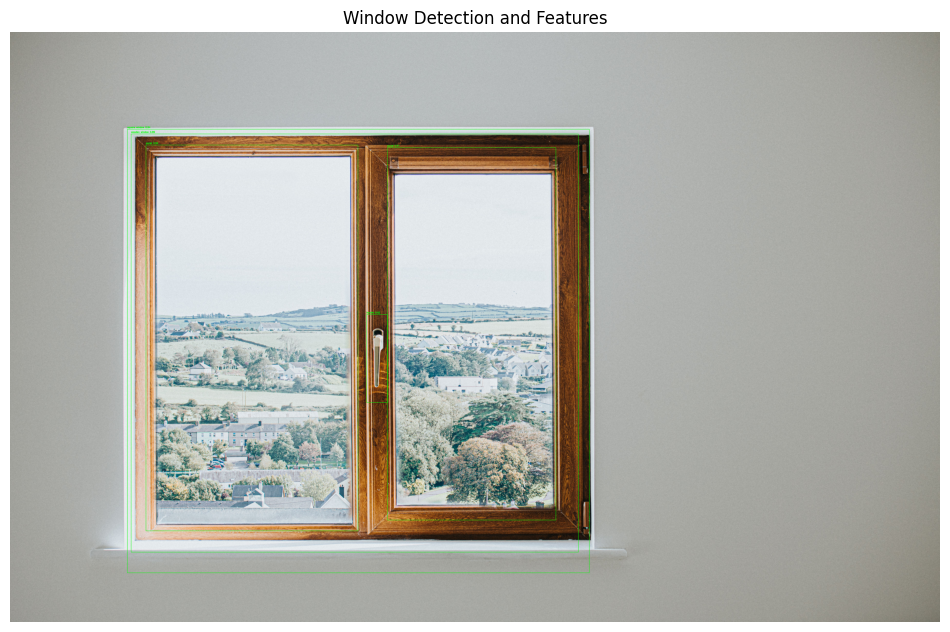

In [ ]:
import requests
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Replace with your actual Roboflow model inference URL
ROBOFLOW_API_URL = "https://detect.roboflow.com/window-rbev3-o1kuc/2"
API_KEY = "vTY1mCJMp9UmHOv0wFQQ"

def detect_window_features(image_path):
    # Open image file in binary mode
    with open(image_path, "rb") as f:
        files = {"file": f}
        # Send POST request to Roboflow inference API
        response = requests.post(
            f"{ROBOFLOW_API_URL}?api_key={API_KEY}",
            files=files,
        )

    if response.status_code != 200:
        print(f"Error: API request failed with status {response.status_code}")
        print(response.text)
        return None

    result = response.json()
    return result

def draw_results(image_path, detections):
    img = cv2.imread(image_path)
    if img is None:
        print("Failed to load image.")
        return

    for obj in detections.get('predictions', []):
        x = int(obj['x'] - obj['width']/2)
        y = int(obj['y'] - obj['height']/2)
        w = int(obj['width'])
        h = int(obj['height'])
        label = obj['class']
        confidence = obj['confidence']

        # Draw bounding box
        cv2.rectangle(img, (x,y), (x+w, y+h), (0,255,0), 2)
        # Draw label and confidence
        cv2.putText(img, f"{label} {confidence:.2f}", (x, y-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2)

    # Show image with matplotlib
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(12,8))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title("Window Detection and Features")
    plt.show()

def main():
    image_path = "/content/wimg1.jpg"  # Replace with your image filename

    detections = detect_window_features(image_path)
    if detections:
        print("Detection Results:")
        for obj in detections.get('predictions', []):
            print(f"Class: {obj['class']}, Confidence: {obj['confidence']:.2f}")
        draw_results(image_path, detections)

if __name__ == "__main__":
    main()
